<a href="https://colab.research.google.com/github/JFD2002/Quant-ESG-Alpha-Lab/blob/Project-1-The-ESG-Risk-Radar-(NLP-Sentiment-Engine)/Daily_News_for_Stock_Market_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
from google.colab import userdata

# Retrieve the token securely from your Colab Secrets
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAG_TOKEN')

# Create the necessary directory for the Kaggle client to work
!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

print("Kaggle environment successfully configured for 2026!")

Kaggle environment successfully configured for 2026!


In [4]:
# Download the dataset files (this will download a .zip file)
!kaggle datasets download -d sumeakash/daily-news-for-stock-market-prediction

# Unzip the file and remove the .zip to keep your workspace clean
!unzip -o daily-news-for-stock-market-prediction.zip
!rm daily-news-for-stock-market-prediction.zip

print("Dataset successfully downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/sumeakash/daily-news-for-stock-market-prediction
License(s): apache-2.0
100% 11.5M/11.5M [00:00<00:00, 12.5MB/s]

Archive:  daily-news-for-stock-market-prediction.zip
  inflating: stock_news_2016 to 2026.csv  
Dataset successfully downloaded and extracted!


In [5]:
import pandas as pd

# 1. Load the dataset
file_path = 'stock_news_2016 to 2026.csv'
df = pd.read_csv(file_path)

# 2. Define our ESG keywords for 2026
# Environmental (E)
e_keywords = ['carbon', 'climate', 'emission', 'green', 'renewable', 'pollution', 'sustainable']
# Social (S)
s_keywords = ['labor', 'diversity', 'employee', 'strike', 'safety', 'human rights', 'community']
# Governance (G)
g_keywords = ['board', 'ceo', 'lawsuit', 'audit', 'compliance', 'scandal', 'bribery', 'shareholder']

all_esg_keywords = e_keywords + s_keywords + g_keywords

# 3. Create a function to flag ESG news
def is_esg(text):
    if pd.isna(text): return False
    text = text.lower()
    return any(word in text for word in all_esg_keywords)

# 4. Apply the filter to the 'title' and 'description' columns
df['is_esg'] = df['title'].apply(is_esg) | df['description'].apply(is_esg)

# 5. Create a specific ESG-only dataframe
df_esg = df[df['is_esg']].copy()

print(f"Total News: {len(df)}")
print(f"ESG-Related News: {len(df_esg)}")
print("\nFirst 5 ESG Headlines:")
print(df_esg['title'].head())

Total News: 139919
ESG-Related News: 5808

First 5 ESG Headlines:
1     IDBI Bank to raise Rs 900 cr through Basel-III...
16          PSU bank employees to go on strike tomorrow
22               BS Banker of the Year is Shikha Sharma
24    PSB employees strike disrupts banking operatio...
26    PSU bank employees on strike, operations hit p...
Name: title, dtype: object


In [6]:
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# 1. Load the FinBERT model and tokenizer
# This is a model specifically trained on financial data (TRC2 and Financial PhraseBank)
model_name = "ProsusAI/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# 2. Create a sentiment analysis pipeline
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=-1) # Set device=0 if using GPU

# 3. Analyze a small sample first to verify efficiency (let's do the first 100)
# Processing 5,800 lines can take time, so we start small.
sample_esg = df_esg.head(100).copy()

def get_finbert_sentiment(text):
    if not text: return "neutral"
    # FinBERT max length is 512 tokens
    result = nlp(text[:512])[0]
    return result['label']

sample_esg['sentiment'] = sample_esg['title'].apply(get_finbert_sentiment)

# 4. View the results
print("Sentiment Analysis on first 100 ESG headlines:")
print(sample_esg[['title', 'sentiment']].head(10))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment Analysis on first 100 ESG headlines:
                                                title sentiment
1   IDBI Bank to raise Rs 900 cr through Basel-III...  positive
16        PSU bank employees to go on strike tomorrow  negative
22             BS Banker of the Year is Shikha Sharma   neutral
24  PSB employees strike disrupts banking operatio...  negative
26  PSU bank employees on strike, operations hit p...  negative
36  Bank of Maharashtra to raise Rs 1,000 cr via t...  positive
40             Rajan bats for more power to RBI board   neutral
43  SBI opens first dedicated banking branch for s...   neutral
44  Running US ops tough on high compliance cost: SBI  positive
97  We're looking at acquisition opportunities: Ra...   neutral


In [7]:
# 1. Prepare the full list of ESG titles
all_titles = df_esg['title'].tolist()

# 2. Run sentiment analysis in batches for speed
print(f"Analyzing sentiment for {len(all_titles)} headlines... this may take 2-4 minutes.")
results = nlp(all_titles, truncation=True, padding=True, batch_size=32)

# 3. Extract the labels and add them back to our ESG dataframe
df_esg['sentiment'] = [result['label'] for result in results]

# 4. Show the ESG Sentiment distribution
print("\nESG Sentiment Distribution:")
print(df_esg['sentiment'].value_counts())

# 5. Quick Check: Show 5 'negative' Governance/Social events
print("\nSample Negative ESG Events (Potential Risk Signals):")
print(df_esg[df_esg['sentiment'] == 'negative']['title'].head())

Analyzing sentiment for 5808 headlines... this may take 2-4 minutes.

ESG Sentiment Distribution:
sentiment
neutral     3392
positive    1363
negative    1053
Name: count, dtype: int64

Sample Negative ESG Events (Potential Risk Signals):
16           PSU bank employees to go on strike tomorrow
24     PSB employees strike disrupts banking operatio...
26     PSU bank employees on strike, operations hit p...
102              Shareholders oppose proposed IPO of TMB
204    SBI employees threaten to go on strike on Budg...
Name: title, dtype: object


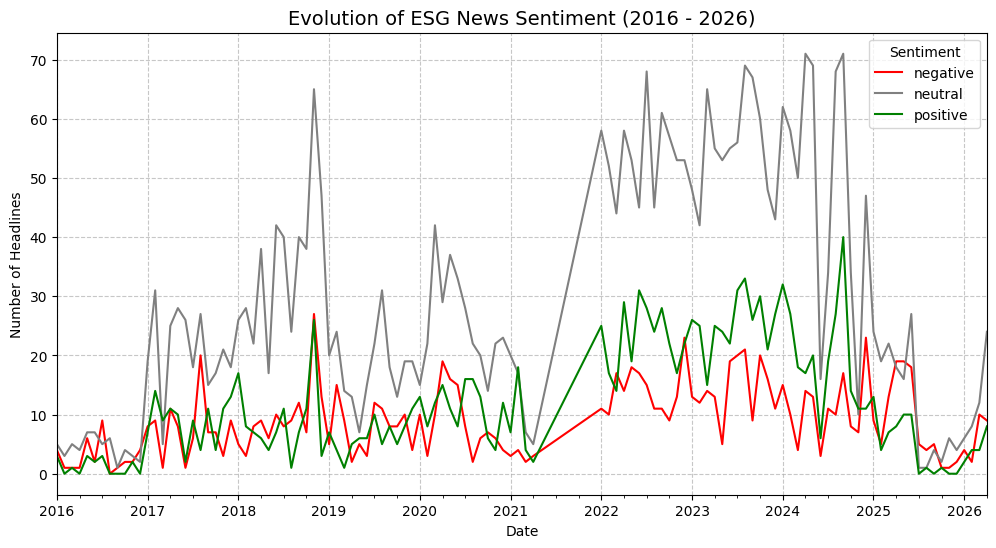

In [8]:
import matplotlib.pyplot as plt

# 1. Convert the date column to a proper datetime format
# Note: Ensure your CSV date column name matches (it might be 'date' or 'timestamp')
df_esg['date'] = pd.to_datetime(df_esg['date'])

# 2. Resample the data by month to see the trend
sentiment_trend = df_esg.groupby([df_esg['date'].dt.to_period('M'), 'sentiment']).size().unstack().fillna(0)

# 3. Create the plot
plt.figure(figsize=(12, 6))
sentiment_trend.plot(kind='line', ax=plt.gca(), color={'negative': 'red', 'positive': 'green', 'neutral': 'gray'})

plt.title('Evolution of ESG News Sentiment (2016 - 2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Sentiment')
plt.show()